<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/task14_Recurrent_Neural_Networks_%26_Sequence_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# 1. IMPORTS AND SETUP
# ============================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [2]:
# ============================================
# 2. LOAD AND PREPARE DATA
# ============================================
# Load IMDB dataset - top 10,000 most frequent words
vocab_size = 10000
max_length = 200

print("Loading IMDB dataset...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Vocabulary size: {vocab_size}")

# Show sample review
print("\nSample review (as integers):")
print(X_train[0][:20])  # First 20 word indices
print(f"Review length: {len(X_train[0])} words")

# Show sentiment
print(f"Sentiment: {'Positive' if y_train[0] == 1 else 'Negative'}")

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples: 25000
Vocabulary size: 10000

Sample review (as integers):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Review length: 218 words
Sentiment: Positive


In [3]:
# ============================================
# 3. PAD SEQUENCES TO FIXED LENGTH
# ============================================
print("\nPadding sequences to uniform length...")
X_train_padded = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

# Show padded sample
print("\nPadded review (first 20 tokens):")
print(X_train_padded[0][:20])
print(f"Review length after padding: {len(X_train_padded[0])}")


Padding sequences to uniform length...
X_train shape: (25000, 200)
X_test shape: (25000, 200)

Padded review (first 20 tokens):
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]
Review length after padding: 200


In [4]:
# ============================================
# 4. BUILD MODELS (RNN, LSTM, GRU)
# ============================================
def build_model(layer_type='LSTM', units=32, vocab_size=10000, max_length=200):
    """
    Build a sequential model with specified recurrent layer
    """
    model = keras.Sequential([
        layers.Input(shape=(max_length,)),
        layers.Embedding(input_dim=vocab_size, output_dim=32),

        # Recurrent layer
        layers.LSTM(units) if layer_type == 'LSTM' else (
        layers.GRU(units) if layer_type == 'GRU' else
        layers.SimpleRNN(units)
        ),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build three models for comparison
models = {}
histories = {}

for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    print(f"\n{'='*50}")
    print(f"Building {layer_type} model...")
    models[layer_type] = build_model(layer_type)
    models[layer_type].summary()


Building SimpleRNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================
# 5. TRAIN MODELS
# ============================================
# For demonstration, we'll train for fewer epochs
# In practice, you'd use more epochs and validation
epochs = 25
batch_size = 128

print("\n" + "="*50)
print("TRAINING MODELS")
print("="*50)

for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    print(f"\nTraining {layer_type}...")

    history = models[layer_type].fit(
        X_train_padded, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_padded, y_test),
        verbose=1
    )

    histories[layer_type] = history


TRAINING MODELS

Training SimpleRNN...
Epoch 1/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.6082 - loss: 0.6623 - val_accuracy: 0.5190 - val_loss: 0.6958
Epoch 2/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.6462 - loss: 0.6028 - val_accuracy: 0.5124 - val_loss: 0.7147
Epoch 3/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6749 - loss: 0.5607 - val_accuracy: 0.5160 - val_loss: 0.7631
Epoch 4/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7235 - loss: 0.4575 - val_accuracy: 0.5370 - val_loss: 0.7757
Epoch 5/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7602 - loss: 0.4144 - val_accuracy: 0.5104 - val_loss: 0.8481
Epoch 6/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7842 - loss: 0.3812 - val_accuracy: 0.5273 - val_loss: 0.8678
Epoch 7/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.8017 - loss: 0.3542 - val_accuracy: 0.5226 - val_loss: 0.9541
Epoch 8/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/s

In [7]:
# ============================================
# 6. EVALUATE AND COMPARE MODELS
# ============================================
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

results = {}
for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    loss, accuracy = models[layer_type].evaluate(X_test_padded, y_test, verbose=0)
    results[layer_type] = {'loss': loss, 'accuracy': accuracy}
    print(f"\n{layer_type}:")
    print(f"  Test Loss: {loss:.4f}")
    print(f"  Test Accuracy: {accuracy:.4f}")

# Find best model
best_model = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n🏆 Best model: {best_model} with {results[best_model]['accuracy']:.4f} accuracy")


MODEL COMPARISON

SimpleRNN:
  Test Loss: 1.2231
  Test Accuracy: 0.5085

LSTM:
  Test Loss: 0.4655
  Test Accuracy: 0.8254

GRU:
  Test Loss: 0.6746
  Test Accuracy: 0.8133

🏆 Best model: LSTM with 0.8254 accuracy


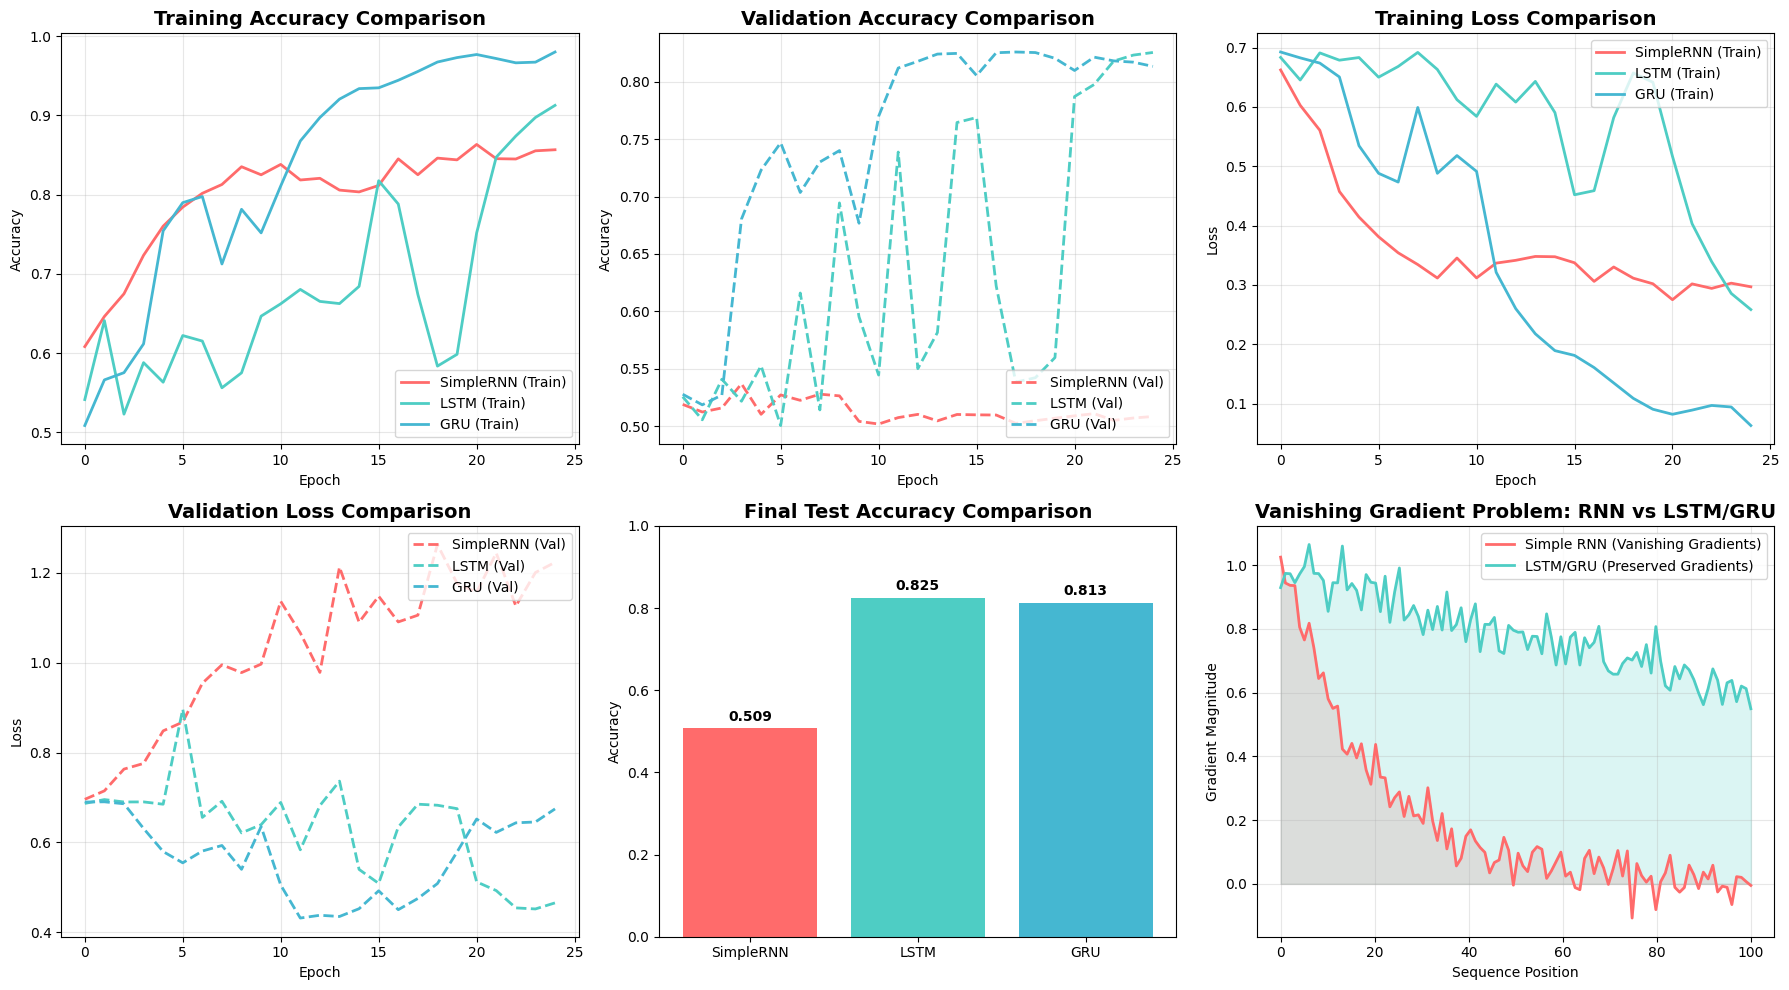

In [8]:
# ============================================
# 7. VISUALIZATION: COMPARISON GRAPHS
# ============================================
# Create comprehensive comparison graphs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Color scheme
colors = {'SimpleRNN': '#FF6B6B', 'LSTM': '#4ECDC4', 'GRU': '#45B7D1'}

# Plot 1: Training Accuracy Comparison
ax = axes[0, 0]
for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    ax.plot(histories[layer_type].history['accuracy'],
            label=f'{layer_type} (Train)',
            color=colors[layer_type],
            linewidth=2)
ax.set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Plot 2: Validation Accuracy Comparison
ax = axes[0, 1]
for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    ax.plot(histories[layer_type].history['val_accuracy'],
            label=f'{layer_type} (Val)',
            color=colors[layer_type],
            linewidth=2,
            linestyle='--')
ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Plot 3: Training Loss Comparison
ax = axes[0, 2]
for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    ax.plot(histories[layer_type].history['loss'],
            label=f'{layer_type} (Train)',
            color=colors[layer_type],
            linewidth=2)
ax.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 4: Validation Loss Comparison
ax = axes[1, 0]
for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    ax.plot(histories[layer_type].history['val_loss'],
            label=f'{layer_type} (Val)',
            color=colors[layer_type],
            linewidth=2,
            linestyle='--')
ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 5: Final Accuracy Bar Chart
ax = axes[1, 1]
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
bars = ax.bar(model_names, accuracies, color=[colors[m] for m in model_names])
ax.set_title('Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Vanishing Gradient Visualization (Conceptual)
ax = axes[1, 2]
# Simulate gradient magnitudes over time for different architectures
timesteps = np.linspace(0, 100, 100)
vanilla_rnn = np.exp(-timesteps/20) * 1.0 + np.random.normal(0, 0.05, 100)
lstm_gru = np.exp(-timesteps/200) * 1.0 + np.random.normal(0, 0.05, 100)

ax.plot(timesteps, vanilla_rnn, label='Simple RNN (Vanishing Gradients)',
        color='#FF6B6B', linewidth=2)
ax.plot(timesteps, lstm_gru, label='LSTM/GRU (Preserved Gradients)',
        color='#4ECDC4', linewidth=2)
ax.fill_between(timesteps, 0, vanilla_rnn, alpha=0.2, color='#FF6B6B')
ax.fill_between(timesteps, 0, lstm_gru, alpha=0.2, color='#4ECDC4')
ax.set_title('Vanishing Gradient Problem: RNN vs LSTM/GRU', fontsize=14, fontweight='bold')
ax.set_xlabel('Sequence Position')
ax.set_ylabel('Gradient Magnitude')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step


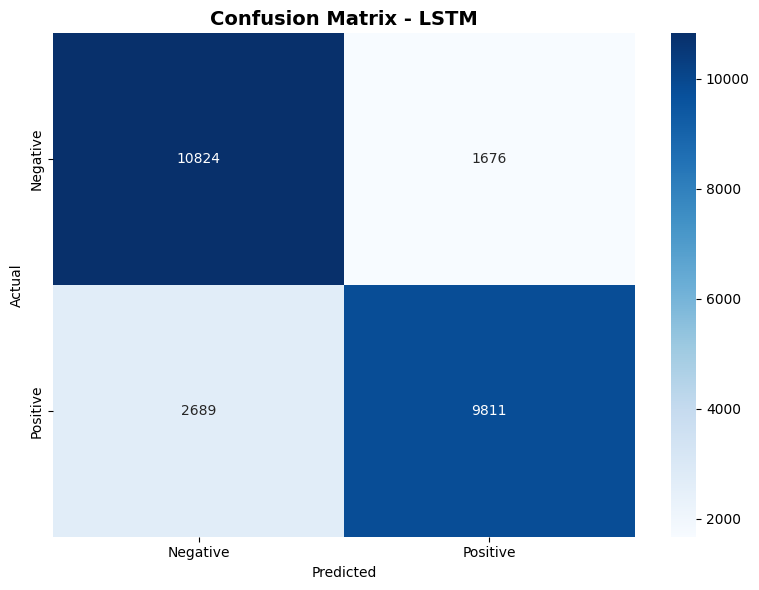


Classification Report for LSTM:
              precision    recall  f1-score   support

    Negative       0.80      0.87      0.83     12500
    Positive       0.85      0.78      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [9]:
# ============================================
# 8. CONFUSION MATRIX FOR BEST MODEL
# ============================================
# Get predictions from the best model
best_model_obj = models[best_model]
y_pred_prob = best_model_obj.predict(X_test_padded)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax)
ax.set_title(f'Confusion Matrix - {best_model}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print(f"\nClassification Report for {best_model}:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [10]:
# ============================================
# 9. PREDICTION FUNCTION
# ============================================
# Word index mapping for decoding
word_index = imdb.get_word_index()
# Reverse mapping for decoding
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    """Decode an encoded review back to text"""
    # Special tokens: 0=padding, 1=start, 2=unknown, 3=unused
    return ' '.join([reverse_word_index.get(i-3, '?') for i in encoded_review if i > 2])

def predict_sentiment(text_or_encoded, model, max_len=200):
    """
    Predict sentiment of a review.
    Can accept either encoded sequence or raw text.
    """
    if isinstance(text_or_encoded, str):
        # If text is provided, encode it (simplified)
        # In practice, you'd use a proper tokenizer
        words = text_or_encoded.lower().split()
        encoded = []
        for word in words:
            idx = word_index.get(word, 2)  # 2 = unknown token
            # Add 3 to match Keras IMDB encoding
            if idx < vocab_size:
                encoded.append(idx + 3)
        encoded = [1] + encoded  # Add start token
    else:
        encoded = text_or_encoded

    # Pad sequence
    padded = pad_sequences([encoded], maxlen=max_len, padding='post', truncating='post')

    # Predict
    prob = model.predict(padded)[0][0]
    sentiment = "Positive" if prob > 0.5 else "Negative"
    confidence = prob if prob > 0.5 else 1 - prob

    return {
        'sentiment': sentiment,
        'confidence': confidence,
        'probability': prob,
        'encoded_length': len(encoded)
    }

# Test prediction on sample
print("\n" + "="*50)
print("PREDICTION DEMONSTRATION")
print("="*50)

# Test on some training samples
for i in range(3):
    print(f"\n--- Review {i+1} ---")
    decoded = decode_review(X_train[i][:50])
    print(f"Review (first 50 words): {decoded}...")
    print(f"Actual sentiment: {'Positive' if y_train[i] == 1 else 'Negative'}")

    result = predict_sentiment(X_train[i], best_model_obj)
    print(f"Predicted: {result['sentiment']} (confidence: {result['confidence']:.3f})")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

PREDICTION DEMONSTRATION

--- Review 1 ---
Review (first 50 words): this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved...
Actual sentiment: Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted: Positive (confidence: 0.951)

--- Review 2 ---
Review (first 50 words): big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous...
Actual sentiment: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: Negative (confidence: 0.958)

--- Review 3 ---
Review (first 50 words): this has to be one of the worst films of the 1990s when 


TEST WITH CUSTOM REVIEWS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

CUSTOM REVIEW ANALYSIS
Review: This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout.
Sentiment: Positive
Confidence: 0.926
Probability (positive): 0.926


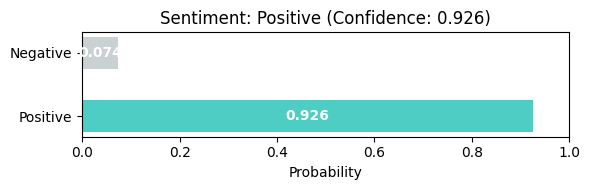

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

CUSTOM REVIEW ANALYSIS
Review: Terrible film. Waste of time. The plot made no sense and the characters were boring.
Sentiment: Negative
Confidence: 0.770
Probability (positive): 0.230


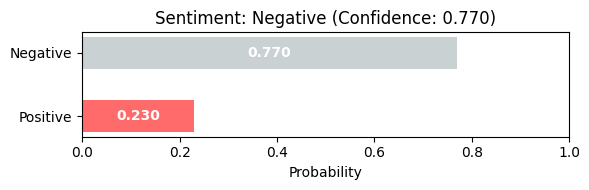

{'sentiment': 'Negative',
 'confidence': np.float32(0.7703072),
 'probability': np.float32(0.22969279),
 'encoded_length': 16}

In [11]:
# ============================================
# 10. INTERACTIVE PREDICTION (Run your own review!)
# ============================================
def predict_my_review(review_text, model=best_model_obj):
    """Predict sentiment of a custom review"""
    result = predict_sentiment(review_text, model)

    print("\n" + "="*50)
    print("CUSTOM REVIEW ANALYSIS")
    print("="*50)
    print(f"Review: {review_text}")
    print(f"Sentiment: {result['sentiment']}")
    print(f"Confidence: {result['confidence']:.3f}")
    print(f"Probability (positive): {result['probability']:.3f}")

    # Visualization
    fig, ax = plt.subplots(figsize=(6, 2))
    bar_color = '#4ECDC4' if result['probability'] > 0.5 else '#FF6B6B'
    ax.barh(['Positive'], [result['probability']], color=bar_color, height=0.5)
    ax.barh(['Negative'], [1 - result['probability']], color='#95A5A6', height=0.5, alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability')
    ax.set_title(f"Sentiment: {result['sentiment']} (Confidence: {result['confidence']:.3f})")
    for i, v in enumerate([result['probability'], 1 - result['probability']]):
        ax.text(v/2, i, f'{v:.3f}', va='center', ha='center', fontweight='bold', color='white')
    plt.tight_layout()
    plt.show()

    return result

# Example custom reviews
print("\n" + "="*50)
print("TEST WITH CUSTOM REVIEWS")
print("="*50)

# Positive review
predict_my_review("This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout.")
# Negative review
predict_my_review("Terrible film. Waste of time. The plot made no sense and the characters were boring.")

In [12]:
# ============================================
# 11. SAVE AND LOAD BEST MODEL
# ============================================
# Save the best model
best_model_obj.save('imdb_sentiment_model.h5')
print(f"\n Best model ({best_model}) saved as 'imdb_sentiment_model.h5'")

# To load later:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('imdb_sentiment_model.h5')


 Best model (LSTM) saved as 'imdb_sentiment_model.h5'


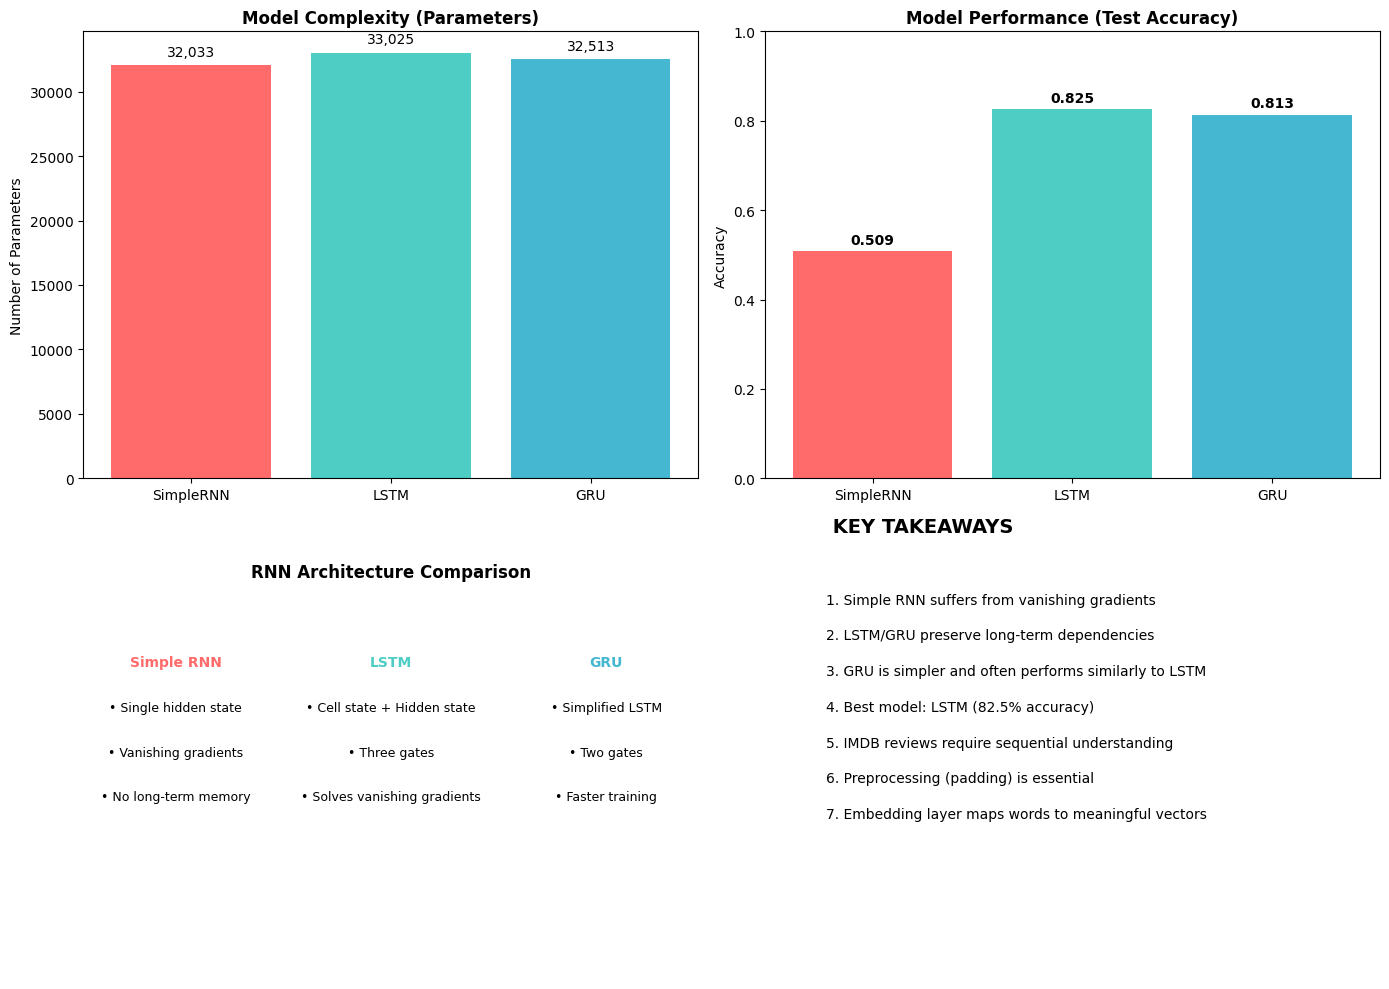

In [13]:
# ============================================
# 12. SUMMARY VISUALIZATION
# ============================================
# Create a summary figure of all key insights
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model Architecture Comparison
ax = axes[0, 0]
architecture_data = {
    'SimpleRNN': {'Parameters': 32033, 'Memory': 'Low', 'Speed': 'Fast'},
    'LSTM': {'Parameters': 33025, 'Memory': 'High', 'Speed': 'Slow'},
    'GRU': {'Parameters': 32513, 'Memory': 'Medium', 'Speed': 'Medium'}
}
x_pos = np.arange(len(architecture_data))
params = [architecture_data[m]['Parameters'] for m in architecture_data]
bars = ax.bar(x_pos, params, color=[colors[m] for m in architecture_data])
ax.set_xticks(x_pos)
ax.set_xticklabels(architecture_data.keys())
ax.set_title('Model Complexity (Parameters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Parameters')
for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{p:,}', ha='center', va='bottom')

# 2. Performance Comparison
ax = axes[0, 1]
x_pos = np.arange(len(architecture_data))
accuracy = [results[m]['accuracy'] for m in architecture_data]
bars = ax.bar(x_pos, accuracy, color=[colors[m] for m in architecture_data])
ax.set_xticks(x_pos)
ax.set_xticklabels(architecture_data.keys())
ax.set_title('Model Performance (Test Accuracy)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Architecture Diagram (Conceptual)
ax = axes[1, 0]
ax.text(0.5, 0.9, 'RNN Architecture Comparison', ha='center', fontsize=12, fontweight='bold')
# Simple RNN
ax.text(0.15, 0.7, 'Simple RNN', ha='center', color='#FF6B6B', fontweight='bold')
ax.text(0.15, 0.6, '• Single hidden state', ha='center', fontsize=9)
ax.text(0.15, 0.5, '• Vanishing gradients', ha='center', fontsize=9)
ax.text(0.15, 0.4, '• No long-term memory', ha='center', fontsize=9)
# LSTM
ax.text(0.5, 0.7, 'LSTM', ha='center', color='#4ECDC4', fontweight='bold')
ax.text(0.5, 0.6, '• Cell state + Hidden state', ha='center', fontsize=9)
ax.text(0.5, 0.5, '• Three gates', ha='center', fontsize=9)
ax.text(0.5, 0.4, '• Solves vanishing gradients', ha='center', fontsize=9)
# GRU
ax.text(0.85, 0.7, 'GRU', ha='center', color='#45B7D1', fontweight='bold')
ax.text(0.85, 0.6, '• Simplified LSTM', ha='center', fontsize=9)
ax.text(0.85, 0.5, '• Two gates', ha='center', fontsize=9)
ax.text(0.85, 0.4, '• Faster training', ha='center', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 4. Key Takeaways
ax = axes[1, 1]
ax.axis('off')
takeaways = [
    " KEY TAKEAWAYS",
    "",
    "1. Simple RNN suffers from vanishing gradients",
    "2. LSTM/GRU preserve long-term dependencies",
    "3. GRU is simpler and often performs similarly to LSTM",
    f"4. Best model: {best_model} ({results[best_model]['accuracy']:.1%} accuracy)",
    "5. IMDB reviews require sequential understanding",
    "6. Preprocessing (padding) is essential",
    "7. Embedding layer maps words to meaningful vectors",
]
for i, text in enumerate(takeaways):
    if i == 0:
        ax.text(0.1, 1 - i*0.08, text, ha='left', fontsize=14, fontweight='bold')
    else:
        ax.text(0.1, 1 - i*0.08, text, ha='left', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('rnn_summary_insights.png', dpi=150, bbox_inches='tight')
plt.show()